# Test 0 --- evidence
Test 0 is on a noiseless dataset

In [1]:
import numpy as np

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import zuko

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
data = np.load("/Users/chang/data/px2cosmo/test0/mock0_N100000fdown10.data.npy")[::1000]

# NSF spline transforms only have support over a bounded interval (default
# bound=5), but the raw data lives around (z_hat, M_uv_hat) ~ (6.8, -17.7)
# with O(1) scatter. Standardize so the flow can actually model the data.
data_mean = data.mean(axis=0)
data_std = data.std(axis=0)
data_norm = (data - data_mean) / data_std

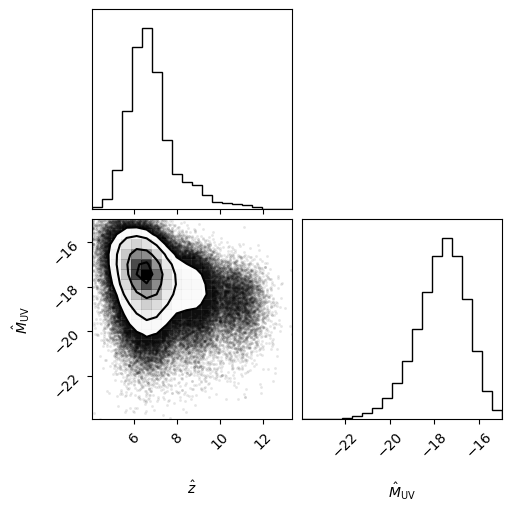

In [5]:
fig = DFM.corner(data, labels=[r'$\hat{z}$', r'$\hat{M}_{\rm UV}$'])

In [6]:
def build_flow(dim_x: int, n_transforms: int = 5, hidden_features: list[int] = [64, 64]) -> zuko.flows.Flow:
    # no context argument -> unconditional flow
    return zuko.flows.NSF(
        features=dim_x,
        transforms=n_transforms,
        hidden_features=hidden_features)

In [7]:
def train_flow(flow, x, n_epochs=100, batch_size=256, lr=5e-4, device='cpu'):
    flow = flow.to(device)
    x = x.to(device)

    loader = DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(flow.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    losses = []
    flow.train()

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for (x_batch,) in loader:
            optimizer.zero_grad()
            # no context -> flow() with no args returns the distribution
            loss = -flow().log_prob(x_batch).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        losses.append(epoch_loss / len(loader))

        if epoch % 10 == 0:
            print(f"epoch {epoch:4d} | loss {losses[-1]:.4f}")

    return losses

@torch.no_grad()
def log_prob(flow: zuko.flows.Flow, x: torch.Tensor, device: str = "cpu") -> torch.Tensor:
    """evaluate log p(x) for a batch of observations."""
    return flow.to(device).eval()().log_prob(x.to(device))

@torch.no_grad()
def sample(flow: zuko.flows.Flow, n_samples: int = 1000, device: str = "cpu") -> torch.Tensor:
    return flow.to(device).eval()().sample((n_samples,))

In [8]:
evid_flow = build_flow(data.shape[1])

In [9]:
ishuffle = np.arange(data.shape[0])
np.random.shuffle(ishuffle)

In [10]:
train_flow(evid_flow, torch.tensor(data_norm[ishuffle][:int(0.9*data.shape[0])].astype(np.float32)), n_epochs=100, batch_size=256, lr=5e-4, device='cpu')

epoch    0 | loss 2.6429
epoch   10 | loss 2.6191
epoch   20 | loss 2.6173
epoch   30 | loss 2.6172
epoch   40 | loss 2.6164
epoch   50 | loss 2.6162
epoch   60 | loss 2.6158
epoch   70 | loss 2.6155
epoch   80 | loss 2.6154
epoch   90 | loss 2.6149


[2.6428665754406953,
 2.6233014490561275,
 2.622219361692128,
 2.621275584211029,
 2.6207700715200537,
 2.619645443381573,
 2.6196495667292474,
 2.6197019297947257,
 2.619198958695089,
 2.6191798417759187,
 2.61906547324602,
 2.6183876510738404,
 2.6185576151815804,
 2.6184744628516894,
 2.618084635537416,
 2.617960505399285,
 2.617882307801752,
 2.6181300592052845,
 2.617795630326875,
 2.617816260926791,
 2.617336911748546,
 2.617359056953312,
 2.6173096134373077,
 2.617450760008445,
 2.6174431349263942,
 2.617425993123412,
 2.616981094813778,
 2.6171215754146724,
 2.6170543435316063,
 2.6169428505022703,
 2.6171885306829012,
 2.6170023008218415,
 2.61679624771887,
 2.6167711044158737,
 2.6168436631367804,
 2.616564714939403,
 2.6167333849948813,
 2.616990101429843,
 2.6167269005639917,
 2.616431618537706,
 2.61636247314532,
 2.616607915831475,
 2.616458294003509,
 2.616313686050494,
 2.61633511230311,
 2.6162547784874297,
 2.6164708288449035,
 2.6163198023803473,
 2.6162407718579592,

## validate NDE

In [11]:
test_data = data[ishuffle][int(0.9*data.shape[0]):]

In [12]:
test_samples = sample(evid_flow, 10000).numpy() * data_std + data_mean

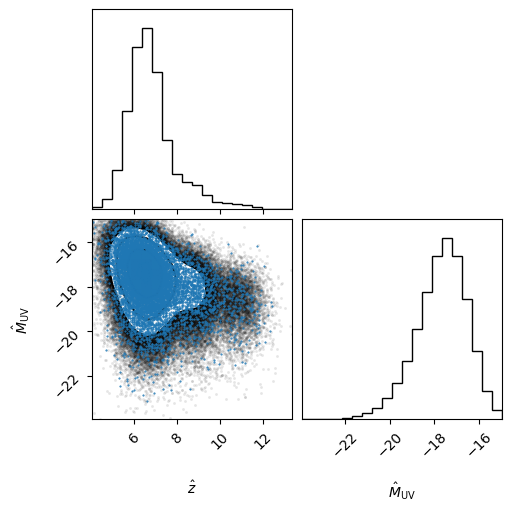

In [18]:
fig = DFM.corner(data, labels=[r'$\hat{z}$', r'$\hat{M}_{\rm UV}$'])
DFM.overplot_points(fig, test_samples, markersize=1)

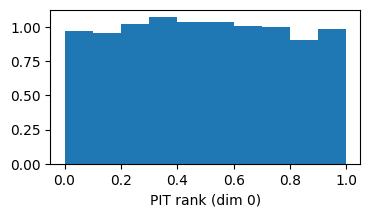

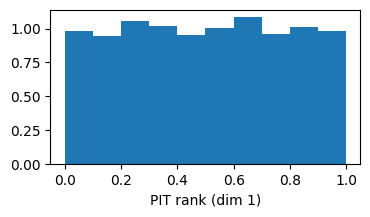

In [20]:
for i in range(test_data.shape[1]):
    ranks = [np.mean(test_samples[:, i] < _td) for _td in test_data[:, i]]
    plt.figure(figsize=(4,2))
    plt.hist(ranks, density=True)
    plt.xlabel(f"PIT rank (dim {i})")
    plt.show()

In [24]:
torch.save(evid_flow, '/Users/chang/data/px2cosmo/test0/mock0_p_X.pt')
np.save('/Users/chang/data/px2cosmo/test0/mock0_X_std.npy', data_std)
np.save('/Users/chang/data/px2cosmo/test0/mock0_X_mean.npy', data_mean)